In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential, Model
from keras.applications.mobilenet import preprocess_input
from keras.preprocessing import image
from keras.layers import Rescaling, Activation, Dense, Flatten, BatchNormalization, Conv2D, MaxPool2D
from keras.optimizers import Adam
from keras.metrics import categorical_crossentropy
from keras.utils import image_dataset_from_directory
from sklearn.metrics import confusion_matrix
import itertools
import os
import shutil
import random
import glob
import matplotlib.pyplot as plt
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)
%matplotlib inline

In [ ]:
physical_devices = tf.config.experimental.list_physical_devices('TPU')
print(physical_devices)
# tf.config.experimental.set_memory_growth(physical_devices[0], True)

[]


In [ ]:
mobile = tf.keras.applications.mobilenet.MobileNet()

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


# Below codes are for testing MobileNet Model

In [ ]:


def prepare_image(file):
  img_path = 'drive/MyDrive/'
  img = image.load_img(img_path + file, target_size=(224, 224))
  img = image.img_to_array(img)
  img_array_expaneded_dims = np.expand_dims(img, axis=0)
  return keras.applications.mobilenet.preprocess_input(img_array_expaneded_dims)

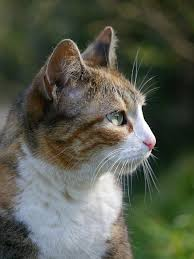

In [ ]:
from IPython.display import Image
# import matplotlib.image as mpimg
# img = mpimg.imread('sample_data/MobileNet-samples/stawberry.jpg')
# imgplot = plt.imshow(img)
Image(filename='drive/MyDrive/pic2.jpg', width=300, height=200)

In [ ]:
from keras.src.applications import imagenet_utils
preprocessed_image = prepare_image('pic2.jpg')
predictions = mobile.predict(preprocessed_image)
results = imagenet_utils.decode_predictions(predictions)
results

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step


[[('n02123159', 'tiger_cat', np.float32(0.65417045)),
  ('n02124075', 'Egyptian_cat', np.float32(0.28027114)),
  ('n02123045', 'tabby', np.float32(0.037960973)),
  ('n02127052', 'lynx', np.float32(0.008985919)),
  ('n02125311', 'cougar', np.float32(0.007881265))]]

## **Loading and preparing Data for Transfer learning**

In [ ]:
# Organize data into train, valid, test dirs

train_path = 'drive/MyDrive/Sign-Language-Digits-Dataset/train'
valid_path = 'drive/MyDrive/Sign-Language-Digits-Dataset/valid'
test_path = 'drive/MyDrive/Sign-Language-Digits-Dataset/test'

In [ ]:
train_batches = image_dataset_from_directory(train_path, labels='inferred', batch_size=10, image_size=(224, 224))
valid_batches = image_dataset_from_directory(valid_path, labels='inferred', batch_size=10, image_size=(224, 224))
test_batches = image_dataset_from_directory(test_path, labels='inferred', batch_size=10, image_size=(224, 224), shuffle=False)


Found 1712 files belonging to 10 classes.
Found 300 files belonging to 10 classes.
Found 50 files belonging to 10 classes.


In [ ]:
def prepare_image(image, lables):
  # Preprocess image using MobileNet's preprocess_input
  processed_image = keras.applications.mobilenet.preprocess_input(image)

  # One-hot encode the labels. Assuming 10 classes based on the model's final layer.
  one_hot_labels = tf.one_hot(lables, depth=10)

  # Reshape one-hot encoded labels to match the model's output shape (batch_size, 1, 1, num_classes)
  reshaped_labels = tf.reshape(one_hot_labels, (-1, 1, 1, 10))

  return processed_image, reshaped_labels

In [ ]:
processed_train_batches = train_batches.map(prepare_image)
processed_valid_batches = valid_batches.map(prepare_image)
processed_test_batches = test_batches.map(prepare_image)

In [ ]:
x, y = next(iter(processed_train_batches))


print(x.shape, y.shape)



(10, 224, 224, 3) (10, 1, 1, 10)


## Modify Model


In [ ]:
mobile = tf.keras.applications.mobilenet.MobileNet()

In [ ]:
mobile.summary()

Model: "mobilenet_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 112, 112, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 112, 112, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 112, 112, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 112, 112, 64)   │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 113, 113, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 56, 56, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 56, 56, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 56, 56, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 56, 56, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 4,253,864 (16.23 MB)

 Trainable params: 4,231,976 (16.14 MB)

 Non-trainable params: 21,888 (85.50 KB)

In [ ]:
mobile.layers[3]

<ReLU name=conv1_relu, built=True>

In [ ]:
x = mobile.layers[-5].output
output = Dense(units=10, activation='softmax')(x)
print(output)

<KerasTensor shape=(None, 1, 1, 10), dtype=float32, sparse=False, ragged=False, name=keras_tensor_645>


In [ ]:
model = Model(inputs=mobile.input, outputs=output)

In [ ]:
for layer in model.layers[:-23]:
  layer.trainable = False

In [ ]:
model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 112, 112, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 112, 112, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 112, 112, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 112, 112, 64)   │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 113, 113, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 56, 56, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 56, 56, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 56, 56, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 56, 56, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 6,986,976 (26.65 MB)

 Trainable params: 1,873,930 (7.15 MB)

 Non-trainable params: 1,365,184 (5.21 MB)

 Optimizer params: 3,747,862 (14.30 MB)

# Train the Model

In [ ]:
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Run for more epochs (~30) to see better results
model.fit(x=processed_train_batches, validation_data=processed_valid_batches, epochs=10, verbose=2)

Epoch 1/10
172/172 - 183s - 1s/step - accuracy: 0.7862 - loss: 0.7702 - val_accuracy: 0.9167 - val_loss: 0.3192
Epoch 2/10
172/172 - 150s - 870ms/step - accuracy: 0.9702 - loss: 0.1422 - val_accuracy: 0.9833 - val_loss: 0.1185
Epoch 3/10
172/172 - 194s - 1s/step - accuracy: 0.9883 - loss: 0.0640 - val_accuracy: 0.9900 - val_loss: 0.0536
Epoch 4/10
172/172 - 180s - 1s/step - accuracy: 0.9959 - loss: 0.0500 - val_accuracy: 0.9933 - val_loss: 0.0392
Epoch 5/10
172/172 - 175s - 1s/step - accuracy: 0.9942 - loss: 0.0306 - val_accuracy: 0.9967 - val_loss: 0.0322
Epoch 6/10
172/172 - 211s - 1s/step - accuracy: 0.9977 - loss: 0.0183 - val_accuracy: 0.9933 - val_loss: 0.0262
Epoch 7/10
172/172 - 155s - 903ms/step - accuracy: 0.9977 - loss: 0.0155 - val_accuracy: 0.9900 - val_loss: 0.0278
Epoch 8/10
172/172 - 148s - 863ms/step - accuracy: 0.9994 - loss: 0.0096 - val_accuracy: 0.9900 - val_loss: 0.0222
Epoch 9/10
172/172 - 152s - 884ms/step - accuracy: 0.9994 - loss: 0.0086 - val_accuracy: 0.9933

## Predict sign language digits

In [ ]:
predictions = model.predict(x=processed_test_batches, verbose=10)

In [ ]:
sklearn.utils.shufle(processed_test_batches)

for img, lables in processed_test_batches:
  print(img.shape, lables)
  for i in range(10):
    l = np.argmax(lables[i], axis=-1)
    print(l)
  break

(10, 224, 224, 3) tf.Tensor(
[[[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]]


 [[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]]


 [[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]]


 [[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]]


 [[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]]


 [[[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]]]


 [[[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]]]


 [[[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]]]


 [[[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]]]


 [[[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]]]], shape=(10, 1, 1, 10), dtype=float32)
[[0]]
[[0]]
[[0]]
[[0]]
[[0]]
[[1]]
[[1]]
[[1]]
[[1]]
[[1]]


In [ ]:
test_labels = np.array([])
for image, labels in processed_test_batches:
  test_labels = np.append(test_labels, np.argmax(labels, axis=-1))

print(test_labels, np.argmax(predictions, axis=-1).reshape(-1,))

[0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 2. 2. 2. 2. 2. 3. 3. 3. 3. 3. 4. 4. 4. 4.
 4. 5. 5. 5. 5. 5. 6. 6. 6. 6. 6. 7. 7. 7. 7. 7. 8. 8. 8. 8. 8. 9. 9. 9.
 9. 9.] [0 0 0 0 0 1 1 1 1 1 2 2 2 2 2 3 3 3 3 3 4 4 4 4 4 5 5 5 5 5 4 6 6 6 6 7 7
 7 7 7 8 8 8 8 8 9 9 9 9 9]


In [ ]:
cm = confusion_matrix(y_true=test_labels, y_pred=predictions.argmax(axis=-1).reshape(-1,))

In [ ]:
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion Matrix', cmap=plt.cm.Blues):


  plt.imshow(cm, interpolation='nearest', cmap=cmap)
  plt.title(title)
  plt.colorbar()

  tick_marks = np.arange(len(classes))
  print(tick_marks, classes)
  plt.xticks(tick_marks, classes, rotation=45)
  plt.yticks(tick_marks, classes)


  if normalize:
    cm=cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    print('Normalized confusion matrix')
  else:
    print('Confusion matrix, without normalization')

  print(cm)

  thresh = cm.max() / 2

  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment="center",
             color="white" if cm[i, j] > thresh else "black")
  plt.tight_layout()
  plt.ylabel('True label')
  plt.xlabel('Predicted label')

[0 1 2 3 4 5 6 7 8 9] ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Confusion matrix, without normalization
[[5 0 0 0 0 0 0 0 0 0]
 [0 5 0 0 0 0 0 0 0 0]
 [0 0 5 0 0 0 0 0 0 0]
 [0 0 0 5 0 0 0 0 0 0]
 [0 0 0 0 5 0 0 0 0 0]
 [0 0 0 0 0 5 0 0 0 0]
 [0 0 0 0 1 0 4 0 0 0]
 [0 0 0 0 0 0 0 5 0 0]
 [0 0 0 0 0 0 0 0 5 0]
 [0 0 0 0 0 0 0 0 0 5]]


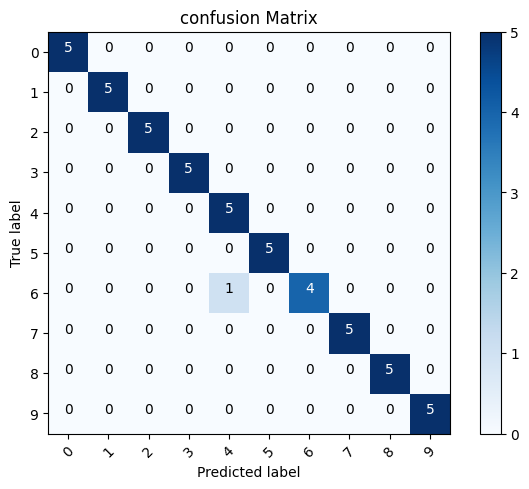

In [ ]:
# Train the model for more epochs to see better results
cm_plot_labels = []
for i in range(10):
  cm_plot_labels.append(str(i))

plot_confusion_matrix(cm=cm, classes=cm_plot_labels, title='confusion Matrix')